# Evaluation Metrics

We evaluate defect prediction models using four key metrics, all computed for the **buggy** (defect‑prone) class.

| Metric | Definition | Why it matters |
|--------|-----------|----------------|
| **Precision (Buggy)** | $\frac{TP}{TP+FP}$ — fraction of predicted buggy commits that are truly buggy. | High precision → fewer false alarms; developers trust the alerts and waste less time reviewing safe commits. |
| **Recall (Buggy)** | $\frac{TP}{TP+FN}$ — fraction of actual buggy commits that are correctly identified. | High recall → fewer missed defects; important when missing a bug has a high cost (e.g., security patches). |
| **F1‑score (Buggy)** | $2\cdot\frac{Precision \cdot Recall}{Precision+Recall}$ — harmonic mean of precision and recall. | Balances precision and recall in a single number; useful when you need a trade‑off and cannot favour one side arbitrarily. |
| **ROC AUC** | Area Under the Receiver Operating Characteristic curve. Measures the probability that a randomly chosen buggy commit is ranked higher than a randomly chosen clean commit. | AUC evaluates the model’s overall **ranking ability** regardless of the decision threshold. AUC = 0.5 is random; AUC = 1.0 is perfect separation. It complements precision/recall by showing how well the model distinguishes the two classes across all possible thresholds. |

### Why these metrics?

In Just‑In‑Time defect prediction, the goal is to **correctly flag risky commits with a limited review budget**.  
- **Precision** tells us if we waste reviewer time.  
- **Recall** tells us if we miss real bugs.  
- **F1** provides a single balanced measure.  
- **AUC** shows if the model is inherently good at ranking commits by risk, even before choosing a concrete threshold.  

Together, they give a holistic picture: a model with high AUC but low precision at default threshold can be tuned (e.g., by adjusting the threshold) to meet a project’s acceptable false‑positive rate, while high recall ensures few defects slip through.

# Vanilla Version

## Installing, imports and data loading

In [1]:
import sys

In [2]:
 xgboost

  Using cached xgboost-3.2.0-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)


  Using cached nvidia_nccl_cu12-2.30.4-py3-none-manylinux_2_18_x86_64.whl.metadata (2.1 kB)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/131.7 MB ? eta -:--:--


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/131.7 MB 828.4 kB/s eta 0:02:40


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/131.7 MB 828.4 kB/s eta 0:02:40

...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 300.2/300.2 MB 8.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 5.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

sns.set_style("whitegrid")
%matplotlib inline

In [3]:
# Load the data
df = pd.read_csv("apachejit_total.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (106674, 18)


,commit_id,project,buggy,fix,year,author_date,la,ld,nf,nd,ns,ent,ndev,age,nuc,aexp,arexp,asexp
0,7b8480744ea6e6fb41efd4329bb470c8f3c763db,apache/groovy,False,False,2003,1070355653,372,23,8,3,3,2.669743,0.250000,3.625000,2.125,243,243.0,0.683585
1,192b631e7be302ecde822546ba70a9853ddbda01,apache/groovy,False,False,2003,1063298262,2,2,2,2,1,1.000000,1.000000,0.000000,2.500,19,19.0,14.000000
2,0ab6465a7dece117c61c3efd3ec95d20524bdad6,apache/groovy,False,False,2003,1069704572,41,26,3,3,2,1.237612,0.666667,5.333333,45.000,233,233.0,0.000606
3,449241d5fa1aeadd5eb9fa1280d4104dc0dfb891,apache/groovy,False,False,2003,1068487625,8,6,2,1,1,0.591673,1.000000,3.000000,35.500,64,64.0,55.000000
4,698df9f5b0816e05bbf97a390428f8ef94e0cdbf,apache/groovy,False,False,2003,1063313516,70,4,6,3,1,2.519672,0.333333,0.000000,6.000,27,27.0,22.000000


## EDA

### Quick data exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106674 entries, 0 to 106673
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   commit_id    106674 non-null  object 
 1   project      106674 non-null  object 
 2   buggy        106674 non-null  bool   
 3   fix          106674 non-null  bool   
 4   year         106674 non-null  int64  
 5   author_date  106674 non-null  int64  
 6   la           106674 non-null  int64  
 7   ld           106674 non-null  int64  
 8   nf           106674 non-null  int64  
 9   nd           106674 non-null  int64  
 10  ns           106674 non-null  int64  
 11  ent          106674 non-null  float64
 12  ndev         106674 non-null  float64
 13  age          106674 non-null  float64
 14  nuc          106674 non-null  float64
 15  aexp         106674 non-null  int64  
 16  arexp        106674 non-null  float64
 17  asexp        106674 non-null  float64
dtypes: bool(2), float64(6), 

In [5]:
# Check target distribution
print("Buggy commits:")
print(df['buggy'].value_counts())
print("\nProportion buggy: {:.2%}".format(df['buggy'].mean()))

Buggy commits:
buggy
False    78435
True     28239
Name: count, dtype: int64

Proportion buggy: 26.47%


### Feature and target selection

In [6]:
# Choose feature columns (No 'Fix' column)
feature_cols = ['la', 'ld', 'nf', 'nd', 'ns', 'ent',
                'ndev', 'age', 'nuc', 'aexp', 'arexp', 'asexp']

X = df[feature_cols].copy()
y = df['buggy'].astype(int)  # False→0, True→1

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (106674, 12)
Target shape: (106674,)


In [7]:
X.isnull().sum()

la       0
ld       0
nf       0
nd       0
ns       0
ent      0
ndev     0
age      0
nuc      0
aexp     0
arexp    0
asexp    0
dtype: int64

In [8]:
# Remove rows with missing values (if any)
mask = X.notnull().all(axis=1)
X = X[mask]
y = y[mask]
print("Shape after dropping NaNs:", X.shape)

Shape after dropping NaNs: (106674, 12)


### Train/Test split (random, 80/20)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train % buggy: {:.2%}".format(y_train.mean()))
print("Test % buggy: {:.2%}".format(y_test.mean()))

Train size: 85339
Test size: 21335
Train % buggy: 26.47%
Test % buggy: 26.47%


## Time series leakage for splitting

In [10]:
# Sort commits by timestamp ascending
df = df.sort_values('author_date').reset_index(drop=True)

# Define train size (e.g. 80% of the data chronologically)
train_size = int(0.8 * len(df))

# Split into train and test
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Extract features and target
X_train = train_df[feature_cols]
y_train = train_df['buggy'].astype(int)

X_test = test_df[feature_cols]
y_test = test_df['buggy'].astype(int)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("Train % buggy: {:.2%}".format(y_train.mean()))
print("Test % buggy: {:.2%}".format(y_test.mean()))
print(f"\nTrain date range: {train_df['author_date'].min()} – {train_df['author_date'].max()}")
print(f"Test date range:  {test_df['author_date'].min()} – {test_df['author_date'].max()}")

Train size: 85339
Test size: 21335
Train % buggy: 29.00%
Test % buggy: 16.35%

Train date range: 1063292086 – 1507309944
Test date range:  1507311599 – 1577381993


## Validation for monitoring in XGBoost and RF

In [11]:
import numpy as np

# Sort by timestamp
df = df.sort_values('author_date').reset_index(drop=True)

# Proportions
train_frac = 0.70
val_frac   = 0.15
test_frac  = 0.15

# Compute split indices
n = len(df)
train_end = int(n * train_frac)
val_end   = int(n * (train_frac + val_frac))

train_df = df.iloc[:train_end]
val_df   = df.iloc[train_end:val_end]
test_df  = df.iloc[val_end:]

# Extract features & target
X_train = train_df[feature_cols]
y_train = train_df['buggy'].astype(int)

X_val = val_df[feature_cols]
y_val = val_df['buggy'].astype(int)

X_test = test_df[feature_cols]
y_test = test_df['buggy'].astype(int)

print("Train size:", X_train.shape[0], f"| % buggy: {y_train.mean():.2%}")
print("Val size:  ", X_val.shape[0],   f"| % buggy: {y_val.mean():.2%}")
print("Test size: ", X_test.shape[0],  f"| % buggy: {y_test.mean():.2%}")
print(f"\nTrain date range: {train_df['author_date'].min()} – {train_df['author_date'].max()}")
print(f"Val date range:   {val_df['author_date'].min()} – {val_df['author_date'].max()}")
print(f"Test date range:  {test_df['author_date'].min()} – {test_df['author_date'].max()}")

Train size: 74671 | % buggy: 29.31%
Val size:   16001 | % buggy: 26.02%
Test size:  16002 | % buggy: 13.66%

Train date range: 1063292086 – 1476726375
Val date range:   1476727384 – 1524833331
Test date range:  1524834364 – 1577381993


### Feature scaling

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Regression

### Train

In [13]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

### Predict and evaluate

In [14]:
# Probabilities for AUC
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Binary predictions (default threshold 0.5)
y_pred = model.predict(X_test_scaled)

print("\nClassification Report - Logistic Regression:")
print(classification_report(y_test, y_pred, target_names=['Non-Buggy', 'Buggy']))

print("ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_prob)))


Classification Report - Logistic Regression:
              precision    recall  f1-score   support

   Non-Buggy       0.93      0.70      0.80     13816
       Buggy       0.27      0.68      0.38      2186

    accuracy                           0.70     16002
   macro avg       0.60      0.69      0.59     16002
weighted avg       0.84      0.70      0.74     16002

ROC AUC: 0.7612


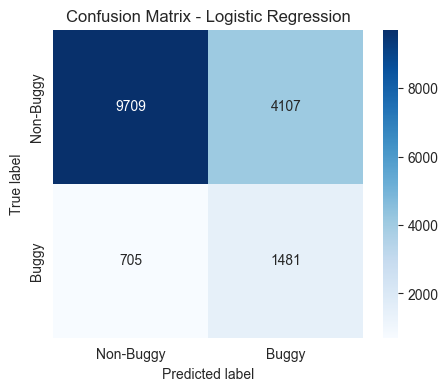

In [15]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Buggy', 'Buggy'],
            yticklabels=['Non-Buggy', 'Buggy'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

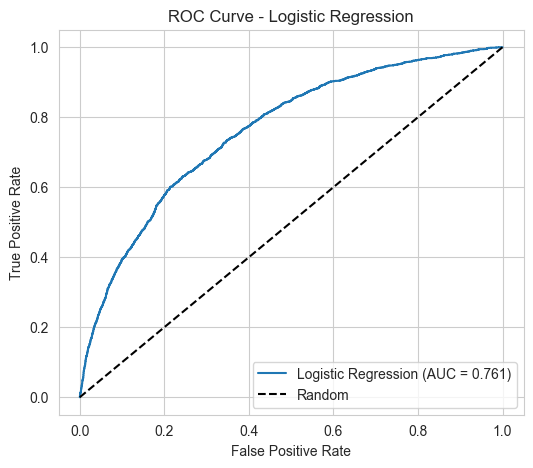

In [16]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Logistic Regression (AUC = {:.3f})'.format(roc_auc_score(y_test, y_prob)))
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

### Performance on the validation set

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train_scaled, y_train)

# Validation metrics
from sklearn.metrics import classification_report, roc_auc_score

y_val_pred = model.predict(X_val_scaled)
y_val_prob = model.predict_proba(X_val_scaled)[:, 1]

print("=== Validation Performance ===")
print(classification_report(y_val, y_val_pred, target_names=['Non-Buggy', 'Buggy']))
print(f"ROC AUC: {roc_auc_score(y_val, y_val_prob):.4f}")

# Test metrics (only after you’re done tuning!)
y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:, 1]
print("=== Final Test Performance ===")
print(classification_report(y_test, y_test_pred, target_names=['Non-Buggy', 'Buggy']))
print(f"ROC AUC: {roc_auc_score(y_test, y_test_prob):.4f}")

=== Validation Performance ===
              precision    recall  f1-score   support

   Non-Buggy       0.86      0.74      0.79     11837
       Buggy       0.46      0.65      0.54      4164

    accuracy                           0.71     16001
   macro avg       0.66      0.69      0.67     16001
weighted avg       0.75      0.71      0.73     16001

ROC AUC: 0.7603
=== Final Test Performance ===
              precision    recall  f1-score   support

   Non-Buggy       0.93      0.70      0.80     13816
       Buggy       0.27      0.68      0.38      2186

    accuracy                           0.70     16002
   macro avg       0.60      0.69      0.59     16002
weighted avg       0.84      0.70      0.74     16002

ROC AUC: 0.7612


## Random Forest

In [19]:
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

### Train - Test

In [20]:
# Train a basic Random Forest with automatic class balancing
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',   # handles imbalance
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Predict
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]
y_pred_rf = rf.predict(X_test_scaled)

### Evaluation

In [21]:
print("\nClassification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=['Non-Buggy', 'Buggy']))

print("ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_rf)))


Classification Report - Random Forest:
              precision    recall  f1-score   support

   Non-Buggy       0.92      0.84      0.88     13816
       Buggy       0.35      0.54      0.42      2186

    accuracy                           0.80     16002
   macro avg       0.63      0.69      0.65     16002
weighted avg       0.84      0.80      0.82     16002

ROC AUC: 0.7847


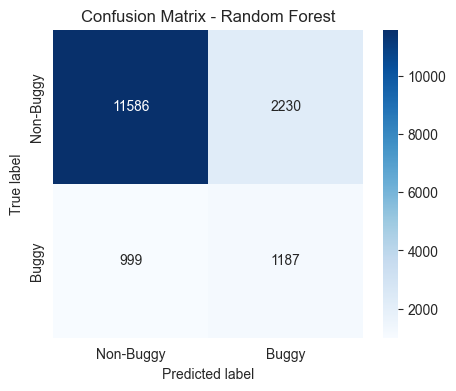

In [22]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Buggy', 'Buggy'],
            yticklabels=['Non-Buggy', 'Buggy'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

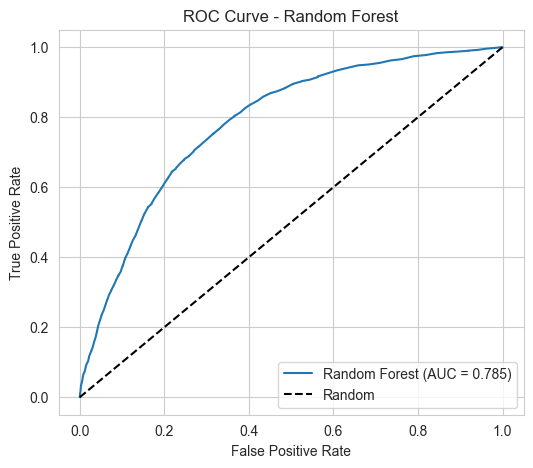

In [23]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='Random Forest (AUC = {:.3f})'.format(roc_auc_score(y_test, y_prob_rf)))
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

### Quick feature importance check

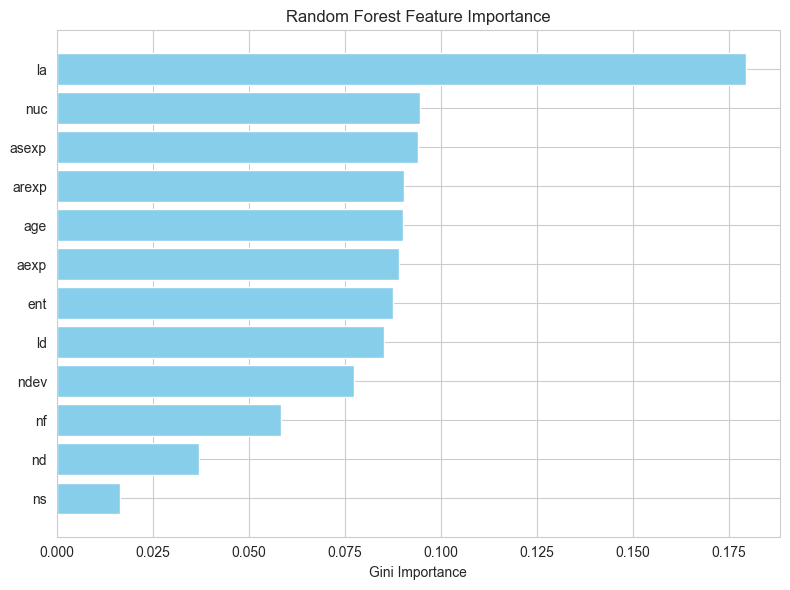

In [24]:
# Random Forest importance plot
rf_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(rf_importance['feature'], rf_importance['importance'], color='skyblue')
plt.xlabel('Gini Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

### Performance on the Validation set

In [25]:
# Random Forest (vanilla settings)
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

# Validation metrics
y_val_pred_rf = rf.predict(X_val_scaled)
y_val_prob_rf = rf.predict_proba(X_val_scaled)[:, 1]

print("=== Random Forest - Validation Performance ===")
print(classification_report(y_val, y_val_pred_rf, target_names=['Non-Buggy', 'Buggy']))
print(f"ROC AUC: {roc_auc_score(y_val, y_val_prob_rf):.4f}")

# Test metrics
y_test_pred_rf = rf.predict(X_test_scaled)
y_test_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("\n=== Random Forest - Final Test Performance ===")
print(classification_report(y_test, y_test_pred_rf, target_names=['Non-Buggy', 'Buggy']))
print(f"ROC AUC: {roc_auc_score(y_test, y_test_prob_rf):.4f}")

=== Random Forest - Validation Performance ===
              precision    recall  f1-score   support

   Non-Buggy       0.84      0.87      0.85     11837
       Buggy       0.59      0.54      0.56      4164

    accuracy                           0.78     16001
   macro avg       0.71      0.70      0.71     16001
weighted avg       0.78      0.78      0.78     16001

ROC AUC: 0.8003

=== Random Forest - Final Test Performance ===
              precision    recall  f1-score   support

   Non-Buggy       0.92      0.84      0.88     13816
       Buggy       0.35      0.54      0.42      2186

    accuracy                           0.80     16002
   macro avg       0.63      0.69      0.65     16002
weighted avg       0.84      0.80      0.82     16002

ROC AUC: 0.7847


## XGBoost

### Train - Test

In [26]:
# Compute scale_pos_weight: number of negative / number of positive
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Train XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,  # imbalance handling
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_scaled, y_train)

# Predict
y_prob_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test_scaled)

scale_pos_weight: 2.41


### Evaluation

In [27]:
print("\nClassification Report - XGBoost:")
print(classification_report(y_test, y_pred_xgb, target_names=['Non-Buggy', 'Buggy']))

print("ROC AUC: {:.4f}".format(roc_auc_score(y_test, y_prob_xgb)))


Classification Report - XGBoost:
              precision    recall  f1-score   support

   Non-Buggy       0.96      0.63      0.76     13816
       Buggy       0.26      0.83      0.40      2186

    accuracy                           0.66     16002
   macro avg       0.61      0.73      0.58     16002
weighted avg       0.86      0.66      0.71     16002

ROC AUC: 0.8015


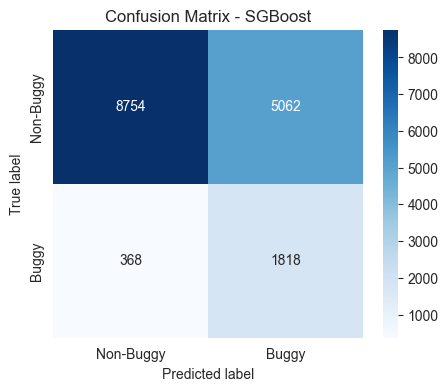

In [28]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Buggy', 'Buggy'],
            yticklabels=['Non-Buggy', 'Buggy'])
plt.title('Confusion Matrix - SGBoost')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()

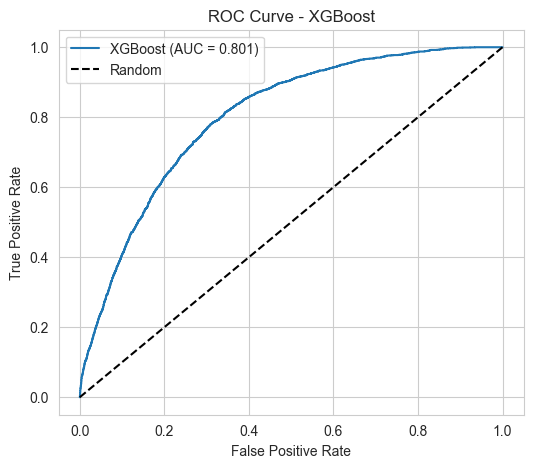

In [29]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='XGBoost (AUC = {:.3f})'.format(roc_auc_score(y_test, y_prob_xgb)))
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.show()

### Quick feature importance check

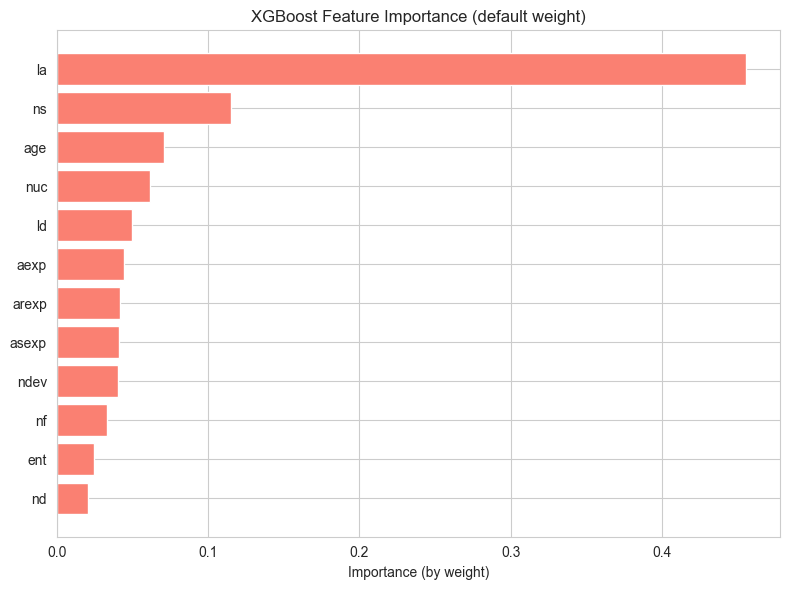

In [30]:
# XGBoost importance (by 'gain')
xgb_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_clf.feature_importances_  # default is 'weight', but 'gain' is often more meaningful
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8,6))
plt.barh(xgb_importance['feature'], xgb_importance['importance'], color='salmon')
plt.xlabel('Importance (by weight)')
plt.title('XGBoost Feature Importance (default weight)')
plt.tight_layout()
plt.show()

### Performance of the Validation set

In [31]:
# Compute scale_pos_weight from training set
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# XGBoost (vanilla settings)
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_clf.fit(X_train_scaled, y_train)

# Validation metrics
y_val_pred_xgb = xgb_clf.predict(X_val_scaled)
y_val_prob_xgb = xgb_clf.predict_proba(X_val_scaled)[:, 1]

print("=== XGBoost - Validation Performance ===")
print(classification_report(y_val, y_val_pred_xgb, target_names=['Non-Buggy', 'Buggy']))
print(f"ROC AUC: {roc_auc_score(y_val, y_val_prob_xgb):.4f}")

# Test metrics
y_test_pred_xgb = xgb_clf.predict(X_test_scaled)
y_test_prob_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

print("\n=== XGBoost - Final Test Performance ===")
print(classification_report(y_test, y_test_pred_xgb, target_names=['Non-Buggy', 'Buggy']))
print(f"ROC AUC: {roc_auc_score(y_test, y_test_prob_xgb):.4f}")

scale_pos_weight: 2.41
=== XGBoost - Validation Performance ===
              precision    recall  f1-score   support

   Non-Buggy       0.91      0.66      0.76     11837
       Buggy       0.45      0.81      0.58      4164

    accuracy                           0.70     16001
   macro avg       0.68      0.73      0.67     16001
weighted avg       0.79      0.70      0.72     16001

ROC AUC: 0.8127

=== XGBoost - Final Test Performance ===
              precision    recall  f1-score   support

   Non-Buggy       0.96      0.63      0.76     13816
       Buggy       0.26      0.83      0.40      2186

    accuracy                           0.66     16002
   macro avg       0.61      0.73      0.58     16002
weighted avg       0.86      0.66      0.71     16002

ROC AUC: 0.8015


## Saving the first Vanilla version results

In [35]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

def get_buggy_metrics(y_true, y_pred):
    """Return precision, recall, f1 for the buggy class (binary)."""
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return p, r, f1

# Logistic Regression (from earlier cells)
prec_lr, rec_lr, f1_lr = get_buggy_metrics(y_test, y_pred)
auc_lr = roc_auc_score(y_test, y_prob)

# Random Forest
prec_rf, rec_rf, f1_rf = get_buggy_metrics(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

# XGBoost
prec_xgb, rec_xgb, f1_xgb = get_buggy_metrics(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)


results = pd.DataFrame({
    'model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'precision_buggy': [prec_lr, prec_rf, prec_xgb],
    'recall_buggy': [rec_lr, rec_rf, rec_xgb],
    'f1_buggy': [f1_lr, f1_rf, f1_xgb],
    'roc_auc': [auc_lr, auc_rf, auc_xgb]
})
print("\n=== Vanilla Baseline Comparison ===")

display(results)

results.to_csv('baseline_results.csv', index=False)
print("Results saved to baseline_results.csv")


=== Vanilla Baseline Comparison ===


,model,precision_buggy,recall_buggy,f1_buggy,roc_auc
0,Logistic Regression,0.265032,0.677493,0.381014,0.761156
1,Random Forest,0.347381,0.543001,0.423702,0.784725
2,XGBoost,0.264244,0.831656,0.401059,0.801500


Results saved to baseline_results.csv


In [34]:
# Create a combined DataFrame of feature importances/coefficients
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'logistic_regression_coef': model.coef_[0],        # model = LogisticRegression
    'random_forest_importance': rf.feature_importances_,
    'xgboost_importance': xgb_clf.feature_importances_  # default = 'weight'
})

# Sort by feature name (or by any importance column)
importance_df = importance_df.sort_values('feature').reset_index(drop=True)

# Save to CSV
importance_df.to_csv('baselines_feature_importances.csv', index=False)
print("Saved combined feature importances to feature_importances.csv")
display(importance_df.head())

Saved combined feature importances to feature_importances.csv


,feature,logistic_regression_coef,random_forest_importance,xgboost_importance
0,aexp,-0.313038,0.089255,0.044685
1,age,-0.040282,0.090137,0.070834
2,arexp,0.037921,0.090528,0.041700
3,asexp,0.127748,0.093995,0.041386
4,ent,0.474142,0.087617,0.024362


## A light HP tuning

### Imports

In [36]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

### TimeSeriesSplit setup

In [37]:
# We'll use 5 splits, each training on an expanding window
tscv = TimeSeriesSplit(n_splits=5)
# Print split sizes to verify time order
for i, (train_idx, test_idx) in enumerate(tscv.split(X_train)):
    print(f"Fold {i}: train indices 0..{train_idx[-1]}, test indices {test_idx[0]}..{test_idx[-1]}")

Fold 0: train indices 0..12445, test indices 12446..24890
Fold 1: train indices 0..24890, test indices 24891..37335
Fold 2: train indices 0..37335, test indices 37336..49780
Fold 3: train indices 0..49780, test indices 49781..62225
Fold 4: train indices 0..62225, test indices 62226..74670


### Hyperparameter grids

In [38]:
# Logistic Regression (simple C values)
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced']
}

# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

# XGBoost
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6, 9],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [scale_pos_weight]  # fixed, computed from train set
}

### GridSearch with TimeSeriesSplit

In [ ]:
from sklearn.metrics import make_scorer, roc_auc_score

def safe_auc(y_true, y_pred_proba):
    """Return roc_auc_score, or 0.5 if only one class is present."""
    unique = np.unique(y_true)
    if len(unique) < 2:
        # Only one class present → random performance
        return 0.5
    return roc_auc_score(y_true, y_pred_proba)

scorer = make_scorer(safe_auc, needs_proba=True)

In [39]:
scorer = make_scorer(roc_auc_score, needs_proba=True)

# Logistic Regression
print("Tuning Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr_gs = GridSearchCV(lr, lr_params, cv=tscv, scoring=scorer, n_jobs=-1)
lr_gs.fit(X_train_scaled, y_train)
print(f"Best LR params: {lr_gs.best_params_}, best CV AUC: {lr_gs.best_score_:.4f}")

# Random Forest
print("\nTuning Random Forest...")
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_gs = GridSearchCV(rf, rf_params, cv=tscv, scoring=scorer, n_jobs=-1)
rf_gs.fit(X_train_scaled, y_train)
print(f"Best RF params: {rf_gs.best_params_}, best CV AUC: {rf_gs.best_score_:.4f}")

# XGBoost
print("\nTuning XGBoost...")
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_gs = GridSearchCV(xgb_clf, xgb_params, cv=tscv, scoring=scorer, n_jobs=-1)
xgb_gs.fit(X_train_scaled, y_train)
print(f"Best XGB params: {xgb_gs.best_params_}, best CV AUC: {xgb_gs.best_score_:.4f}")

Tuning Logistic Regression...
Best LR params: {'C': 0.01, 'class_weight': 'balanced'}, best CV AUC: nan

Tuning Random Forest...
Best RF params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}, best CV AUC: nan

Tuning XGBoost...
Best XGB params: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 2.4113481657453515}, best CV AUC: nan


### Retrain final models with best hyperparameters

In [ ]:
best_lr = lr_gs.best_estimator_
best_rf = rf_gs.best_estimator_
best_xgb = xgb_gs.best_estimator_

### Evaluate on validation and test sets

In [41]:
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

def evaluate_model(model, X_val, y_val, X_test, y_test, name):
    # Validation
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]
    val_auc = roc_auc_score(y_val, y_val_prob)
    print(f"\n{name} - Validation:")
    print(classification_report(y_val, y_val_pred, target_names=['Non-Buggy', 'Buggy']))
    print(f"Val AUC: {val_auc:.4f}")
    
    # Test (final)
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:,1]
    test_auc = roc_auc_score(y_test, y_test_prob)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='binary')
    print(f"{name} - Test AUC: {test_auc:.4f}")
    return {'model': name, 
            'precision_buggy': prec, 'recall_buggy': rec, 
            'f1_buggy': f1, 'roc_auc': test_auc}

results = []
results.append(evaluate_model(best_lr,  X_val_scaled, y_val, X_test_scaled, y_test, 'Logistic Regression'))
results.append(evaluate_model(best_rf,  X_val_scaled, y_val, X_test_scaled, y_test, 'Random Forest'))
results.append(evaluate_model(best_xgb, X_val_scaled, y_val, X_test_scaled, y_test, 'XGBoost'))


Logistic Regression - Validation:
              precision    recall  f1-score   support

   Non-Buggy       0.86      0.74      0.79     11837
       Buggy       0.46      0.65      0.54      4164

    accuracy                           0.71     16001
   macro avg       0.66      0.69      0.67     16001
weighted avg       0.75      0.71      0.73     16001

Val AUC: 0.7604
Logistic Regression - Test AUC: 0.7611

Random Forest - Validation:
              precision    recall  f1-score   support

   Non-Buggy       0.84      0.87      0.85     11837
       Buggy       0.59      0.54      0.56      4164

    accuracy                           0.78     16001
   macro avg       0.71      0.70      0.71     16001
weighted avg       0.78      0.78      0.78     16001

Val AUC: 0.8003
Random Forest - Test AUC: 0.7847

XGBoost - Validation:
              precision    recall  f1-score   support

   Non-Buggy       0.91      0.62      0.74     11837
       Buggy       0.43      0.82      0.57   

### Append to results

In [42]:
import pandas as pd
import os

# Evaluation of tuned models (assuming best_lr, best_rf, best_xgb are already trained)
def evaluate_model(model, X_val, y_val, X_test, y_test, name):
    from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

    # Validation
    y_val_pred = model.predict(X_val)
    y_val_prob = model.predict_proba(X_val)[:,1]
    val_auc = roc_auc_score(y_val, y_val_prob)
    print(f"\n{name} - Validation:")
    print(classification_report(y_val, y_val_pred, target_names=['Non-Buggy', 'Buggy']))
    print(f"Val AUC: {val_auc:.4f}")
    
    # Test
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:,1]
    test_auc = roc_auc_score(y_test, y_test_prob)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='binary')
    print(f"{name} - Test AUC: {test_auc:.4f}")
    return {
        'model': name,
        'precision_buggy': prec,
        'recall_buggy': rec,
        'f1_buggy': f1,
        'roc_auc': test_auc
    }

# Collect results
tuned_results = []
tuned_results.append(evaluate_model(best_lr,  X_val_scaled, y_val, X_test_scaled, y_test, 'Logistic Regression (tuned)'))
tuned_results.append(evaluate_model(best_rf,  X_val_scaled, y_val, X_test_scaled, y_test, 'Random Forest (tuned)'))
tuned_results.append(evaluate_model(best_xgb, X_val_scaled, y_val, X_test_scaled, y_test, 'XGBoost (tuned)'))

tuned_df = pd.DataFrame(tuned_results)

# Append to existing baseline_results.csv
csv_path = 'baseline_results.csv'
if os.path.exists(csv_path):
    existing = pd.read_csv(csv_path)
    # Avoid exact duplicate rows if re‑running
    existing = existing[~existing['model'].isin(tuned_df['model'])]
    combined = pd.concat([existing, tuned_df], ignore_index=True)
else:
    combined = tuned_df

combined.to_csv(csv_path, index=False)
print(f"\nTuned results appended to {csv_path}")
display(combined)


Logistic Regression (tuned) - Validation:
              precision    recall  f1-score   support

   Non-Buggy       0.86      0.74      0.79     11837
       Buggy       0.46      0.65      0.54      4164

    accuracy                           0.71     16001
   macro avg       0.66      0.69      0.67     16001
weighted avg       0.75      0.71      0.73     16001

Val AUC: 0.7604
Logistic Regression (tuned) - Test AUC: 0.7611

Random Forest (tuned) - Validation:
              precision    recall  f1-score   support

   Non-Buggy       0.84      0.87      0.85     11837
       Buggy       0.59      0.54      0.56      4164

    accuracy                           0.78     16001
   macro avg       0.71      0.70      0.71     16001
weighted avg       0.78      0.78      0.78     16001

Val AUC: 0.8003
Random Forest (tuned) - Test AUC: 0.7847

XGBoost (tuned) - Validation:
              precision    recall  f1-score   support

   Non-Buggy       0.91      0.62      0.74     11837
      

,model,precision_buggy,recall_buggy,f1_buggy,roc_auc
0,Logistic Regression,0.265032,0.677493,0.381014,0.761156
1,Random Forest,0.347381,0.543001,0.423702,0.784725
2,XGBoost,0.264244,0.831656,0.401059,0.801500
3,Logistic Regression (tuned),0.264407,0.677951,0.380439,0.761119
4,Random Forest (tuned),0.347381,0.543001,0.423702,0.784726
5,XGBoost (tuned),0.248990,0.845837,0.384727,0.802316


## Online (sequential) evaluation of tuned vanilla models

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# The test set from the chronological split (must be sorted by author_date)
test_indices = test_df.index  # to keep original order if needed
test_timestamps = test_df['author_date'].values  # for x-axis
y_test_true = y_test.values  # ground truth

# Models to evaluate
models = {
    'Logistic Regression (tuned)': best_lr,
    'Random Forest (tuned)': best_rf,
    'XGBoost (tuned)': best_xgb
}

# We'll store cumulative metrics for each model
cumulative_metrics = {name: {'timestamps': [], 'precision': [], 'recall': [], 'f1': [], 'auc': []}
                      for name in models}

for name, model in models.items():
    y_true_cum = []
    y_pred_cum = []
    y_score_cum = []
    
    # Iterate through test set in chronological order
    for i in range(len(y_test_true)):
        # Features for this single commit (must match preprocessed format)
        x_single = X_test_scaled[i].reshape(1, -1)
        y_true = y_test_true[i]
        
        # Predict
        y_pred = model.predict(x_single)[0]
        y_score = model.predict_proba(x_single)[0, 1]
        
        # Update cumulative arrays
        y_true_cum.append(y_true)
        y_pred_cum.append(y_pred)
        y_score_cum.append(y_score)
        
        # Compute cumulative metrics (after at least one positive and one negative for AUC)
        if i > 0 and len(set(y_true_cum)) > 1:
            cum_prec = precision_score(y_true_cum, y_pred_cum)
            cum_rec = recall_score(y_true_cum, y_pred_cum)
            cum_f1 = f1_score(y_true_cum, y_pred_cum)
            cum_auc = roc_auc_score(y_true_cum, y_score_cum)
        else:
            cum_prec = cum_rec = cum_f1 = cum_auc = np.nan
        
        cumulative_metrics[name]['timestamps'].append(test_timestamps[i])
        cumulative_metrics[name]['precision'].append(cum_prec)
        cumulative_metrics[name]['recall'].append(cum_rec)
        cumulative_metrics[name]['f1'].append(cum_f1)
        cumulative_metrics[name]['auc'].append(cum_auc)

# ----- Plotting cumulative metrics over time -----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metric_names = ['precision', 'recall', 'f1', 'auc']
axes = axes.flatten()

for ax, metric in zip(axes, metric_names):
    for name in models:
        ax.plot(cumulative_metrics[name]['timestamps'],
                cumulative_metrics[name][metric],
                label=name, alpha=0.8)
    ax.set_title(f'Cumulative {metric.upper()} over test period')
    ax.set_xlabel('Commit timestamp (Unix)')
    ax.set_ylabel(metric.upper())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

# Embedding-based Baseline

## Install dependencies

In [84]:
import sys
!{sys.executable} -m pip install transformers torch tqdm

  Using cached transformers-5.7.0-py3-none-any.whl.metadata (33 kB)


  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)


  Using cached huggingface_hub-1.13.0-py3-none-any.whl.metadata (14 kB)


  Using cached pyyaml-6.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)


  Using cached regex-2026.4.4-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)


...


   ━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━ 30.7/58.4 kB 730.5 kB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━ 51.2/58.4 kB 421.4 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 344.8 kB/s eta 0:00:00
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached click-8.3.3-py3-none-any.whl (110 kB)
Using cached cuda_pathfinder-1.5.4-py3-none-any.whl (51 kB)


Using cached hf_xet-1.4.3-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.2 MB)
Using cached httpx-0.28.1-py3-none-any.whl (73 kB)
Using cached httpcore-1.0.9-py3-none-any.whl (78 kB)


Using cached markupsafe-3.0.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (22 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached rich-15.0.0-py3-none-any.whl (310 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
Using cached markdown_it_py-4.0.0-py3-none-any.whl (87 kB)
Using cached anyio-4.13.0-py3-none-any.whl (114 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)


Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)


In [91]:
!{sys.executable} -m pip install ipywidgets

  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)


  Using cached widgetsnbextension-4.0.15-py3-none-any.whl.metadata (1.6 kB)


  Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl.metadata (20 kB)


Using cached ipywidgets-8.1.8-py3-none-any.whl (139 kB)
Using cached jupyterlab_widgets-3.0.16-py3-none-any.whl (914 kB)


Using cached widgetsnbextension-4.0.15-py3-none-any.whl (2.2 MB)


## CodeBERT

### Load the dataset with diffs

In [85]:
import pandas as pd
import numpy as np

df_diff = pd.read_csv("apachejit_with_diffs_v2.csv")
print("Shape:", df_diff.shape)
df_diff.head()

Shape: (95984, 39)


,commit_id,project,buggy,year,author_date,la,ld,nf,nd,ns,...,ld_log,churn_log,aexp_log,arexp_log,asexp_log,km_cluster,dbscan_cluster,hdbscan_cluster,agg_cluster,diff_text
0,7b8480744ea6e6fb41efd4329bb470c8f3c763db,apache/groovy,False,2003,1070355653,372,23,8,3,3,...,3.178054,5.981414,5.497168,5.497168,0.520925,0,0,6,1,"@@ -1,9 +1,42 @@\n <?xml version=""1.0"" encodin..."
1,192b631e7be302ecde822546ba70a9853ddbda01,apache/groovy,False,2003,1063298262,2,2,2,2,1,...,1.098612,1.609438,2.995732,2.995732,2.708050,1,1,8,2,"@@ -549,7 +549,7 @@ public class Token\n \n ..."
2,0ab6465a7dece117c61c3efd3ec95d20524bdad6,apache/groovy,False,2003,1069704572,41,26,3,3,2,...,3.295837,4.219508,5.455321,5.455321,0.000606,2,0,6,1,"@@ -111,8 +111,6 @@ Core Groovy Tasks\n \tuse ..."
3,449241d5fa1aeadd5eb9fa1280d4104dc0dfb891,apache/groovy,False,2003,1068487625,8,6,2,1,1,...,1.945910,2.708050,4.174387,4.174387,4.025352,1,1,8,0,"@@ -617,6 +617,8 @@ public class ASTBuilder\n ..."
4,698df9f5b0816e05bbf97a390428f8ef94e0cdbf,apache/groovy,False,2003,1063313516,70,4,6,3,1,...,1.609438,4.317488,3.332205,3.332205,3.135494,4,1,8,0,"@@ -83,6 +83,9 @@ public class Token\n /**..."


In [86]:
df_diff['diff_text'].isna().sum()

np.int64(1873)

In [87]:
df_diff = df_diff.dropna(subset=['diff_text']).reset_index(drop=True)
print("After dropping NaNs:", df_diff.shape)

After dropping NaNs: (94111, 39)


### Load CodeBERT model and tokenizer from local path

In [88]:
import torch
from transformers import AutoTokenizer, AutoModel

model_path = "./hf_models/codebert"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModel.from_pretrained(model_path)

# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 40486.35it/s]

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropou

### Embedding generator

In [99]:
import os
import numpy as np
from tqdm import tqdm
import shutil

FULL_EMBEDDING_FILE = "codebert_embeddings.npy"
CHUNK_DIR = "embedding_chunks"
CHUNK_SIZE = 1000       # save every 1000 samples

def get_cls_embeddings(texts, tokenizer, model, batch_size=32, max_length=512,
                       full_file=FULL_EMBEDDING_FILE, chunk_dir=CHUNK_DIR,
                       chunk_size=CHUNK_SIZE):
    """Generate [CLS] embeddings with incremental save & resume capability."""
    
    # If final file already exists, load it
    if os.path.exists(full_file):
        print(f"Loading existing embeddings from {full_file}")
        return np.load(full_file)
    
    os.makedirs(chunk_dir, exist_ok=True)
    
    # Resume logic: find existing chunks
    existing_chunks = sorted([
        f for f in os.listdir(chunk_dir)
        if f.startswith("emb_chunk_") and f.endswith(".npy")
    ])
    already_processed = 0
    if existing_chunks:
        # Calculate total number of samples already saved
        for chunk_file in existing_chunks:
            part = np.load(os.path.join(chunk_dir, chunk_file))
            already_processed += len(part)
        print(f"Resuming from sample {already_processed} (found {len(existing_chunks)} chunks)")
    
    # Process remaining texts
    total = len(texts)
    # tqdm with miniters=100 to reduce log spam
    with tqdm(total=total, initial=already_processed, miniters=100, desc="Embedding") as pbar:
        i = already_processed
        while i < total:
            # Define current chunk boundaries
            end = min(i + chunk_size, total)
            chunk_texts = texts[i:end].tolist()
            
            # Embed the chunk in mini‑batches
            chunk_embeddings = []
            for j in range(0, len(chunk_texts), batch_size):
                batch = chunk_texts[j:j+batch_size]
                inputs = tokenizer(batch, return_tensors='pt', padding=True,
                                   truncation=True, max_length=max_length)
                inputs = {k: v.to(device) for k, v in inputs.items()}
                with torch.no_grad():
                    outputs = model(**inputs)
                    
                # cls = outputs.last_hidden_state[:, 0, :].cpu().numpy()

                # ---------- NEW: mean pooling over all tokens (ignoring padding) ----------
                attention_mask = inputs['attention_mask']          # (batch, seq_len)
                embeddings = outputs.last_hidden_state             # (batch, seq_len, hidden_dim)
                mask = attention_mask.unsqueeze(-1).expand(embeddings.size()).float()
                sum_embeddings = (embeddings * mask).sum(1)        # sum over seq_len
                sum_mask = mask.sum(1)                              # number of real tokens
                cls = (sum_embeddings / sum_mask).cpu().numpy()    # mean representation
                # -------------------------------------------------------------------------

                chunk_embeddings.append(cls)
                pbar.update(len(batch))
            
            # Save the chunk to disk
            chunk_array = np.vstack(chunk_embeddings)
            chunk_filename = os.path.join(chunk_dir, f"emb_chunk_{end}.npy")
            np.save(chunk_filename, chunk_array)
            # No print inside the loop – tqdm handles progress
            i = end
    
    # Merge all chunks into one final file
    print("Merging chunks into final file...")
    all_chunk_files = sorted(
        [f for f in os.listdir(chunk_dir) if f.startswith("emb_chunk_") and f.endswith(".npy")]
    )
    parts = []
    for cf in all_chunk_files:
        parts.append(np.load(os.path.join(chunk_dir, cf)))
    full_embeddings = np.vstack(parts)
    np.save(full_file, full_embeddings)
    
    # Cleanup chunk directory
    shutil.rmtree(chunk_dir)
    print(f"Full embeddings saved to {full_file}")
    return full_embeddings

### Generate all embeddings

In [100]:
diff_texts = df_diff['diff_text']
print("Generating CodeBERT embeddings (checkpointed)...")
X_emb = get_cls_embeddings(diff_texts, tokenizer, model, batch_size=32, max_length=512)
print("Embeddings shape:", X_emb.shape)

Generating CodeBERT embeddings (checkpointed)...



Embedding:   0%|          | 0/94111 [00:00<?, ?it/s]


Embedding:   0%|          | 32/94111 [00:11<9:46:15,  2.67it/s]


Embedding:   0%|          | 64/94111 [00:24<10:11:29,  2.56it/s]


Embedding:   0%|          | 96/94111 [00:41<11:36:08,  2.25it/s]

...


Embedding: 100%|█████████▉| 94096/94111 [13:59:18<00:08,  1.81it/s]


Embedding: 100%|██████████| 94111/94111 [13:59:26<00:00,  1.82it/s]


Embedding: 100%|██████████| 94111/94111 [13:59:26<00:00,  1.87it/s]

Merging chunks into final file...


Full embeddings saved to codebert_embeddings.npy
Embeddings shape: (94111, 768)


### Train/Test split

In [101]:
y = df_diff['buggy'].astype(int)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_emb, X_test_emb, y_train, y_test = train_test_split(
    X_emb, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features
scaler_emb = StandardScaler()
X_train_emb_scaled = scaler_emb.fit_transform(X_train_emb)
X_test_emb_scaled = scaler_emb.transform(X_test_emb)

### Train and evaluate the three models (on embeddings)

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_fscore_support

def get_buggy_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return p, r, f1

# Logistic Regression
lr_emb = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_emb.fit(X_train_emb_scaled, y_train)
y_prob_lr = lr_emb.predict_proba(X_test_emb_scaled)[:, 1]
y_pred_lr = lr_emb.predict(X_test_emb_scaled)

# Random Forest
rf_emb = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf_emb.fit(X_train_emb_scaled, y_train)
y_prob_rf = rf_emb.predict_proba(X_test_emb_scaled)[:, 1]
y_pred_rf = rf_emb.predict(X_test_emb_scaled)

# XGBoost
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
xgb_emb = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                            scale_pos_weight=scale_pos_weight, random_state=42,
                            use_label_encoder=False, eval_metric='logloss')
xgb_emb.fit(X_train_emb_scaled, y_train)
y_prob_xgb = xgb_emb.predict_proba(X_test_emb_scaled)[:, 1]
y_pred_xgb = xgb_emb.predict(X_test_emb_scaled)

# Collect metrics
models_dict = {
    'Logistic Regression (CodeBERT)': (y_pred_lr, y_prob_lr),
    'Random Forest (CodeBERT)': (y_pred_rf, y_prob_rf),
    'XGBoost (CodeBERT)': (y_pred_xgb, y_prob_xgb)
}

new_results = []
for name, (ypred, yprob) in models_dict.items():
    prec, rec, f1 = get_buggy_metrics(y_test, ypred)
    auc = roc_auc_score(y_test, yprob)
    new_results.append({
        'model': name,
        'precision_buggy': prec,
        'recall_buggy': rec,
        'f1_buggy': f1,
        'roc_auc': auc
    })
    print(f"\n=== {name} ===")
    print(classification_report(y_test, ypred, target_names=['Non-Buggy', 'Buggy']))
    print(f"ROC AUC: {auc:.4f}")

new_results_df = pd.DataFrame(new_results)
display(new_results_df)


=== Logistic Regression (CodeBERT) ===
              precision    recall  f1-score   support

   Non-Buggy       0.81      0.54      0.65     15102
       Buggy       0.21      0.50      0.30      3721

    accuracy                           0.53     18823
   macro avg       0.51      0.52      0.47     18823
weighted avg       0.69      0.53      0.58     18823

ROC AUC: 0.5257

=== Random Forest (CodeBERT) ===
              precision    recall  f1-score   support

   Non-Buggy       0.80      1.00      0.89     15102
       Buggy       0.27      0.01      0.01      3721

    accuracy                           0.80     18823
   macro avg       0.54      0.50      0.45     18823
weighted avg       0.70      0.80      0.72     18823

ROC AUC: 0.5196

=== XGBoost (CodeBERT) ===
              precision    recall  f1-score   support

   Non-Buggy       0.81      0.68      0.74     15102
       Buggy       0.21      0.35      0.26      3721

    accuracy                           0.62     

,model,precision_buggy,recall_buggy,f1_buggy,roc_auc
0,Logistic Regression (CodeBERT),0.210592,0.501209,0.296573,0.525708
1,Random Forest (CodeBERT),0.268293,0.005912,0.011570,0.519558
2,XGBoost (CodeBERT),0.212689,0.347756,0.263947,0.518070


### Append to "*baseline_results.csv*"

In [103]:
import os

csv_path = 'baseline_results.csv'
if os.path.exists(csv_path):
    old_results = pd.read_csv(csv_path)
    combined = pd.concat([old_results, new_results_df], ignore_index=True)
else:
    combined = new_results_df

combined.to_csv(csv_path, index=False)
print(f"\nUpdated {csv_path} saved.")
display(combined)


Updated baseline_results.csv saved.


,model,precision_buggy,recall_buggy,f1_buggy,roc_auc
0,Logistic Regression,0.453562,0.631197,0.527835,0.740546
1,Random Forest,0.678178,0.392882,0.497534,0.804592
2,XGBoost,0.496604,0.737960,0.593690,0.812123
3,Logistic Regression (CodeBERT),0.210592,0.501209,0.296573,0.525708
4,Random Forest (CodeBERT),0.268293,0.005912,0.011570,0.519558
5,XGBoost (CodeBERT),0.212689,0.347756,0.263947,0.518070


## Visulaizations

                            model  precision_buggy  recall_buggy  f1_buggy  \
0             Logistic Regression         0.453562      0.631197  0.527835   
1                   Random Forest         0.678178      0.392882  0.497534   
2                         XGBoost         0.496604      0.737960  0.593690   
3  Logistic Regression (CodeBERT)         0.210592      0.501209  0.296573   
4        Random Forest (CodeBERT)         0.268293      0.005912  0.011570   
5              XGBoost (CodeBERT)         0.212689      0.347756  0.263947   

    roc_auc  
0  0.740546  
1  0.804592  
2  0.812123  
3  0.525708  
4  0.519558  
5  0.518070  


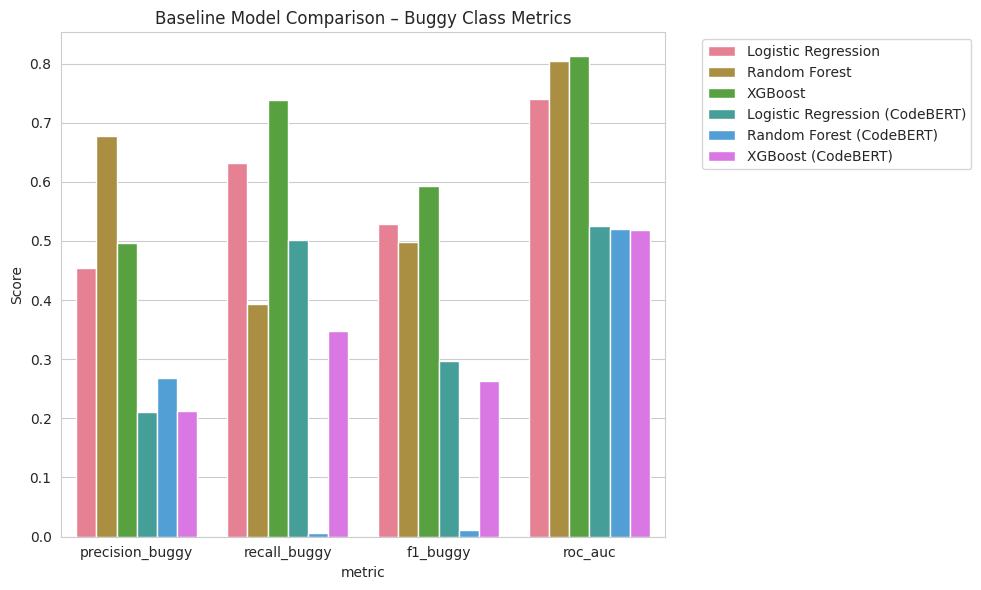

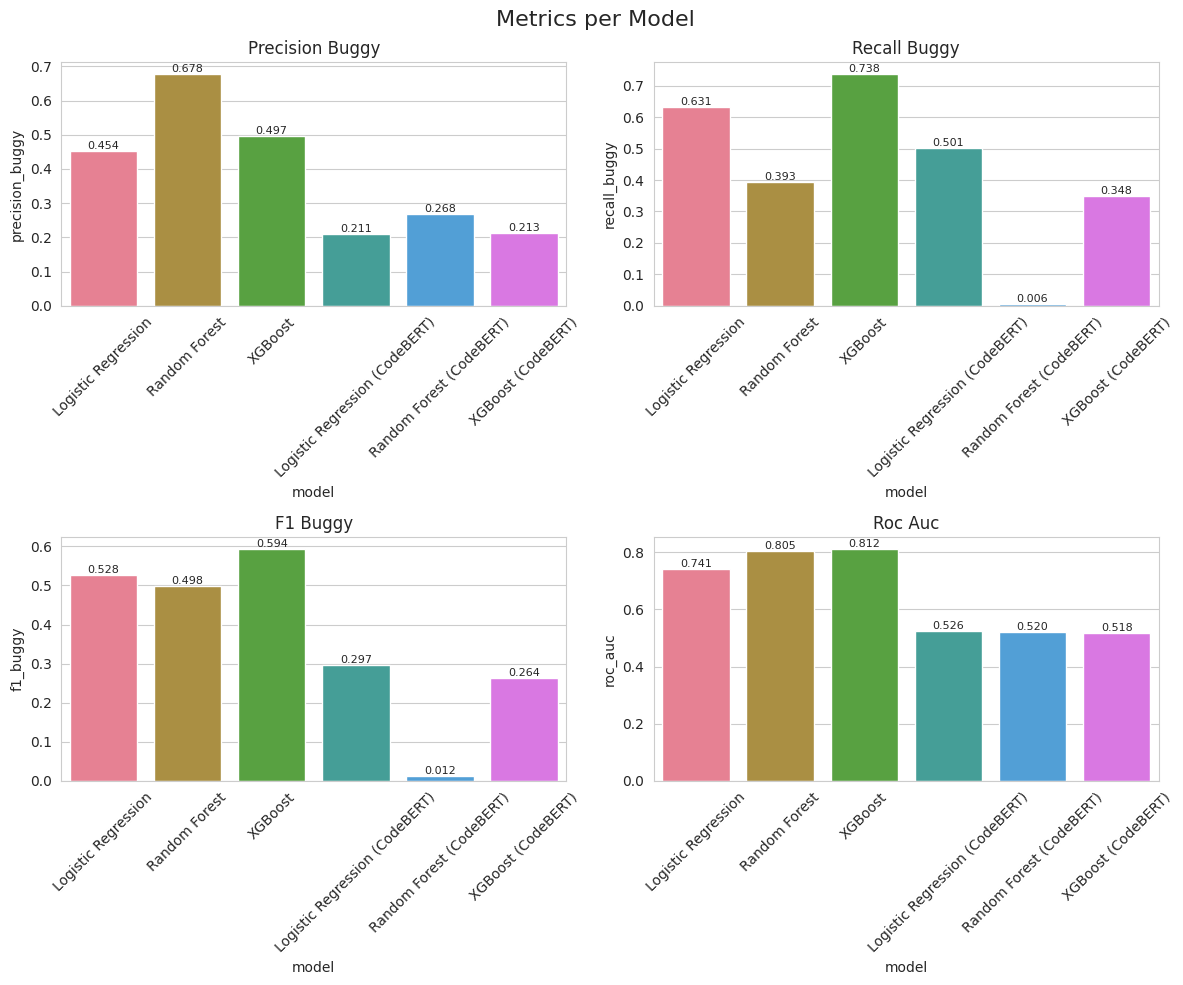

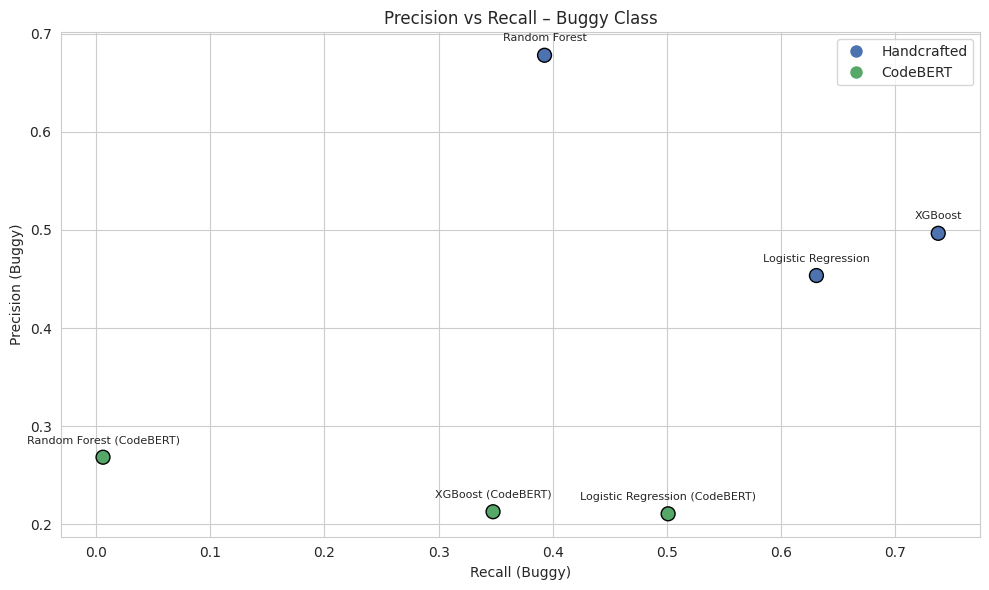

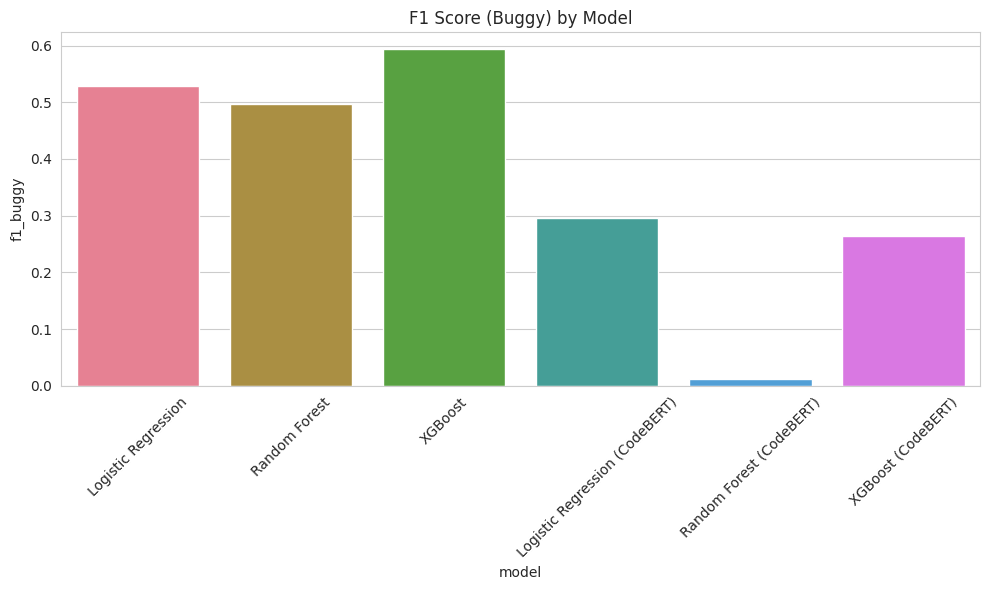

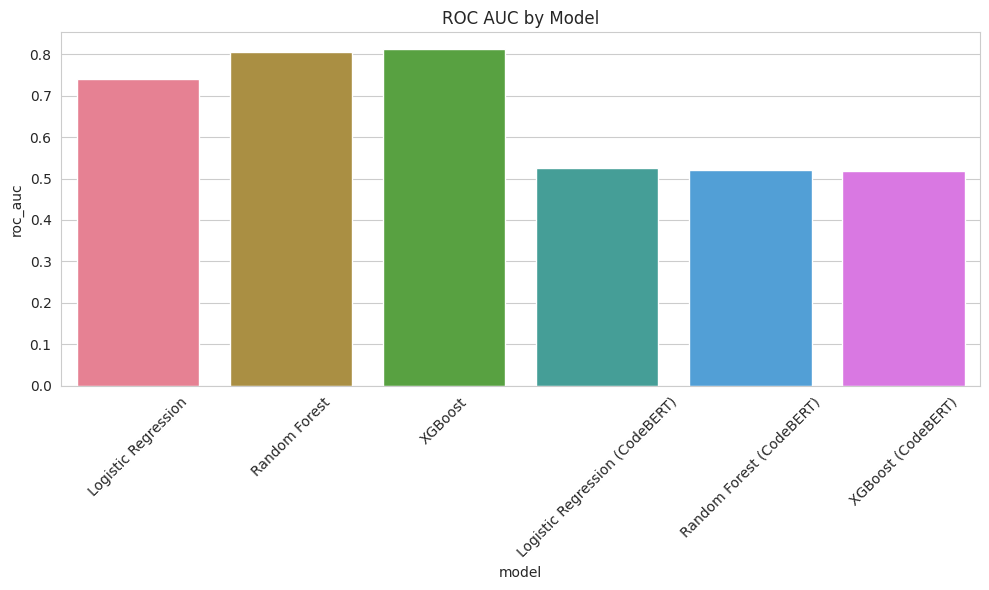

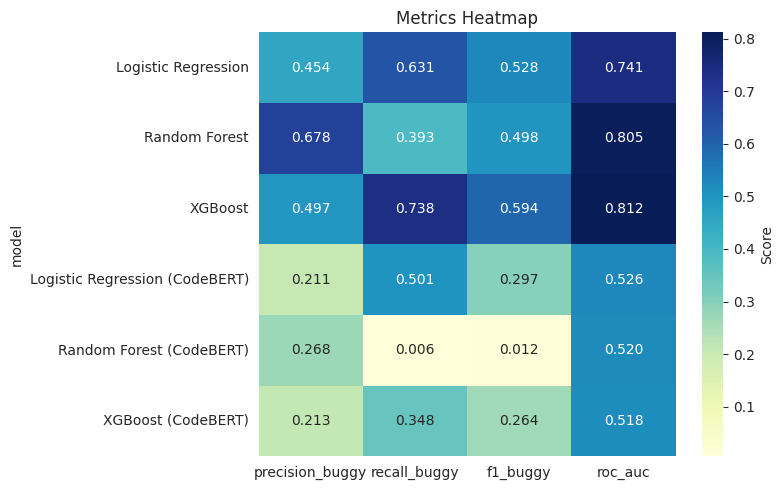

In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results
df = pd.read_csv('baseline_results.csv')
print(df)


# Define approach grouping (reusable column)
df['approach'] = np.where(df['model'].str.contains('CodeBERT'), 'CodeBERT', 'Handcrafted')

metrics = ['precision_buggy', 'recall_buggy', 'f1_buggy', 'roc_auc']
group_colors = {'Handcrafted': '#4C72B0', 'CodeBERT': '#55A868'}

# 1. Grouped bar chart (all metrics, all models)
df_melted = df.melt(id_vars=['model', 'approach'], value_vars=metrics,
                    var_name='metric', value_name='value')

plt.figure()
sns.barplot(data=df_melted, x='metric', y='value', hue='model',
            palette=sns.color_palette("husl", 6))
plt.title('Baseline Model Comparison – Buggy Class Metrics')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Faceted bar charts (one subplot per metric)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=df, x='model', y=metric, hue='model',
                palette=sns.color_palette("husl", 6), ax=ax, legend=False)
    ax.set_title(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.suptitle('Metrics per Model', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Precision – Recall scatter plot (fixed)
plt.figure()
# Use the already computed approach column
colors = [group_colors[a] for a in df['approach']]
plt.scatter(df['recall_buggy'], df['precision_buggy'], c=colors, s=100, edgecolors='k')
for i, row in df.iterrows():
    plt.annotate(row['model'], (row['recall_buggy'], row['precision_buggy']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Recall (Buggy)')
plt.ylabel('Precision (Buggy)')
plt.title('Precision vs Recall – Buggy Class')
handles = [plt.Line2D([0],[0], marker='o', color='w', label='Handcrafted',
                     markerfacecolor=group_colors['Handcrafted'], markersize=10),
          plt.Line2D([0],[0], marker='o', color='w', label='CodeBERT',
                     markerfacecolor=group_colors['CodeBERT'], markersize=10)]
plt.legend(handles=handles)
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. F1 score bar chart
plt.figure()
sns.barplot(data=df, x='model', y='f1_buggy', palette=sns.color_palette("husl", 6))
plt.title('F1 Score (Buggy) by Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. ROC AUC bar chart
plt.figure()
sns.barplot(data=df, x='model', y='roc_auc', palette=sns.color_palette("husl", 6))
plt.title('ROC AUC by Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Heatmap of all metrics
heatmap_data = df.set_index('model')[metrics]
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Score'})
plt.title('Metrics Heatmap')
plt.tight_layout()
plt.show()

# TF-IDF baseline

## Imports and load data

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import (classification_report, roc_auc_score, precision_recall_fscore_support)
import os

# 1. Load data (same as used for CodeBERT)
df_diff = pd.read_csv("apachejit_with_diffs_v2.csv")
df_diff = df_diff.dropna(subset=['diff_text']).reset_index(drop=True)

X_text = df_diff['diff_text']
y = df_diff['buggy'].astype(int)

## Split and Vectorization

In [2]:
X_train_text, X_test_text, y_train_tfidf, y_test_tfidf = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

# 3. TF‑IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    sublinear_tf=True,          # 1 + log(tf)
    ngram_range=(1, 2),         # unigrams + bigrams
    stop_words='english',
    max_df=0.7                  # ignore very frequent terms
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"TF‑IDF matrix shape: {X_train_tfidf.shape}")

TF‑IDF matrix shape: (75288, 5000)


## Classification

In [3]:
def get_buggy_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return p, r, f1

# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train_tfidf)
y_prob_lr = lr.predict_proba(X_test_tfidf)[:, 1]
y_pred_lr = lr.predict(X_test_tfidf)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_tfidf, y_train_tfidf)
y_prob_rf = rf.predict_proba(X_test_tfidf)[:, 1]
y_pred_rf = rf.predict(X_test_tfidf)

# XGBoost
neg, pos = np.bincount(y_train_tfidf)
scale_pos_weight = neg / pos
xgb_clf = xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                            scale_pos_weight=scale_pos_weight, random_state=42,
                            use_label_encoder=False, eval_metric='logloss')
xgb_clf.fit(X_train_tfidf, y_train_tfidf)
y_prob_xgb = xgb_clf.predict_proba(X_test_tfidf)[:, 1]
y_pred_xgb = xgb_clf.predict(X_test_tfidf)

/root/my_jupyter_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:23:35] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Results

In [4]:
models_tfidf = {
    'Logistic Regression (TF‑IDF)': (y_pred_lr, y_prob_lr),
    'Random Forest (TF‑IDF)': (y_pred_rf, y_prob_rf),
    'XGBoost (TF‑IDF)': (y_pred_xgb, y_prob_xgb)
}

new_results = []
for name, (ypred, yprob) in models_tfidf.items():
    prec, rec, f1 = get_buggy_metrics(y_test_tfidf, ypred)
    auc = roc_auc_score(y_test_tfidf, yprob)
    new_results.append({
        'model': name,
        'precision_buggy': prec,
        'recall_buggy': rec,
        'f1_buggy': f1,
        'roc_auc': auc
    })
    print(f"\n=== {name} ===")
    print(classification_report(y_test_tfidf, ypred, target_names=['Non-Buggy', 'Buggy']))
    print(f"ROC AUC: {auc:.4f}")


=== Logistic Regression (TF‑IDF) ===
              precision    recall  f1-score   support

   Non-Buggy       0.93      0.80      0.86     15102
       Buggy       0.49      0.76      0.60      3721

    accuracy                           0.80     18823
   macro avg       0.71      0.78      0.73     18823
weighted avg       0.84      0.80      0.81     18823

ROC AUC: 0.8631

=== Random Forest (TF‑IDF) ===
              precision    recall  f1-score   support

   Non-Buggy       0.86      0.97      0.91     15102
       Buggy       0.75      0.34      0.46      3721

    accuracy                           0.85     18823
   macro avg       0.80      0.65      0.69     18823
weighted avg       0.84      0.85      0.82     18823

ROC AUC: 0.8435

=== XGBoost (TF‑IDF) ===
              precision    recall  f1-score   support

   Non-Buggy       0.93      0.81      0.87     15102
       Buggy       0.50      0.74      0.59      3721

    accuracy                           0.80     18823


In [5]:
csv_path = 'baseline_results.csv'
if os.path.exists(csv_path):
    old = pd.read_csv(csv_path)
    combined = pd.concat([old, pd.DataFrame(new_results)], ignore_index=True)
else:
    combined = pd.DataFrame(new_results)
combined.to_csv(csv_path, index=False)
print(f"\nUpdated {csv_path} with TF‑IDF results.")
display(combined)


Updated baseline_results.csv with TF‑IDF results.


,model,precision_buggy,recall_buggy,f1_buggy,roc_auc
0,Logistic Regression,0.453562,0.631197,0.527835,0.740546
1,Random Forest,0.678178,0.392882,0.497534,0.804592
2,XGBoost,0.496604,0.737960,0.593690,0.812123
3,Logistic Regression (CodeBERT),0.210592,0.501209,0.296573,0.525708
4,Random Forest (CodeBERT),0.268293,0.005912,0.011570,0.519558
5,XGBoost (CodeBERT),0.212689,0.347756,0.263947,0.518070
6,Logistic Regression (TF‑IDF),0.489189,0.760011,0.595243,0.863118
7,Random Forest (TF‑IDF),0.752565,0.335125,0.463741,0.843494
8,XGBoost (TF‑IDF),0.496046,0.741736,0.594507,0.860767


# Random and Naive baselines

## 3 models

In [6]:
y_test = y_test_tfidf
train_buggy_ratio = y_train_tfidf.mean()

# 1. Random baseline
np.random.seed(42)
y_pred_random = (np.random.rand(len(y_test)) < train_buggy_ratio).astype(int)
y_prob_random = np.full_like(y_pred_random, train_buggy_ratio, dtype=float)

# 2. All Non‑Buggy
y_pred_all_clean = np.zeros(len(y_test), dtype=int)
y_prob_all_clean = np.zeros(len(y_test), dtype=float)  # probability of buggy = 0

# 3. All Buggy
y_pred_all_buggy = np.ones(len(y_test), dtype=int)
y_prob_all_buggy = np.ones(len(y_test), dtype=float)   # probability of buggy = 1

## Evaluation

In [7]:
def get_buggy_metrics(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='binary')
    return p, r, f1

baselines = {
    'Random (proportional)': (y_pred_random, y_prob_random),
    'All Non‑Buggy': (y_pred_all_clean, y_prob_all_clean),
    'All Buggy': (y_pred_all_buggy, y_prob_all_buggy)
}

new_baseline_results = []
for name, (ypred, yprob) in baselines.items():
    prec, rec, f1 = get_buggy_metrics(y_test, ypred)
    auc = roc_auc_score(y_test, yprob)
    new_baseline_results.append({
        'model': name,
        'precision_buggy': prec,
        'recall_buggy': rec,
        'f1_buggy': f1,
        'roc_auc': auc
    })
    print(f"\n=== {name} ===")
    print(classification_report(y_test, ypred, target_names=['Non-Buggy', 'Buggy']))
    print(f"ROC AUC: {auc:.4f}")


=== Random (proportional) ===
              precision    recall  f1-score   support

   Non-Buggy       0.80      0.80      0.80     15102
       Buggy       0.21      0.21      0.21      3721

    accuracy                           0.69     18823
   macro avg       0.51      0.51      0.51     18823
weighted avg       0.69      0.69      0.69     18823

ROC AUC: 0.5000

=== All Non‑Buggy ===
              precision    recall  f1-score   support

   Non-Buggy       0.80      1.00      0.89     15102
       Buggy       0.00      0.00      0.00      3721

    accuracy                           0.80     18823
   macro avg       0.40      0.50      0.45     18823
weighted avg       0.64      0.80      0.71     18823

ROC AUC: 0.5000

=== All Buggy ===
              precision    recall  f1-score   support

   Non-Buggy       0.00      0.00      0.00     15102
       Buggy       0.20      1.00      0.33      3721

    accuracy                           0.20     18823
   macro avg       0.10

/root/my_jupyter_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/my_jupyter_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/my_jupyter_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/root/my_jupyte

In [8]:
csv_path = 'baseline_results.csv'
if os.path.exists(csv_path):
    old = pd.read_csv(csv_path)
    combined = pd.concat([old, pd.DataFrame(new_baseline_results)], ignore_index=True)
else:
    combined = pd.DataFrame(new_baseline_results)
combined.to_csv(csv_path, index=False)
print(f"\nUpdated {csv_path} with Random & Naive baselines.")
display(combined)


Updated baseline_results.csv with Random & Naive baselines.


,model,precision_buggy,recall_buggy,f1_buggy,roc_auc
0,Logistic Regression,0.453562,0.631197,0.527835,0.740546
1,Random Forest,0.678178,0.392882,0.497534,0.804592
2,XGBoost,0.496604,0.737960,0.593690,0.812123
3,Logistic Regression (CodeBERT),0.210592,0.501209,0.296573,0.525708
4,Random Forest (CodeBERT),0.268293,0.005912,0.011570,0.519558
5,XGBoost (CodeBERT),0.212689,0.347756,0.263947,0.518070
6,Logistic Regression (TF‑IDF),0.489189,0.760011,0.595243,0.863118
7,Random Forest (TF‑IDF),0.752565,0.335125,0.463741,0.843494
8,XGBoost (TF‑IDF),0.496046,0.741736,0.594507,0.860767
9,Random (proportional),0.208144,0.208815,0.208479,0.500000


# Visulaizations

                             model  precision_buggy  recall_buggy  f1_buggy  \
0              Logistic Regression         0.453562      0.631197  0.527835   
1                    Random Forest         0.678178      0.392882  0.497534   
2                          XGBoost         0.496604      0.737960  0.593690   
3   Logistic Regression (CodeBERT)         0.210592      0.501209  0.296573   
4         Random Forest (CodeBERT)         0.268293      0.005912  0.011570   
5               XGBoost (CodeBERT)         0.212689      0.347756  0.263947   
6     Logistic Regression (TF‑IDF)         0.489189      0.760011  0.595243   
7           Random Forest (TF‑IDF)         0.752565      0.335125  0.463741   
8                 XGBoost (TF‑IDF)         0.496046      0.741736  0.594507   
9            Random (proportional)         0.208144      0.208815  0.208479   
10                   All Non‑Buggy         0.000000      0.000000  0.000000   
11                       All Buggy         0.197684 

/tmp/ipykernel_1560177/712783174.py:22: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_melted, x='metric', y='value', hue='model',


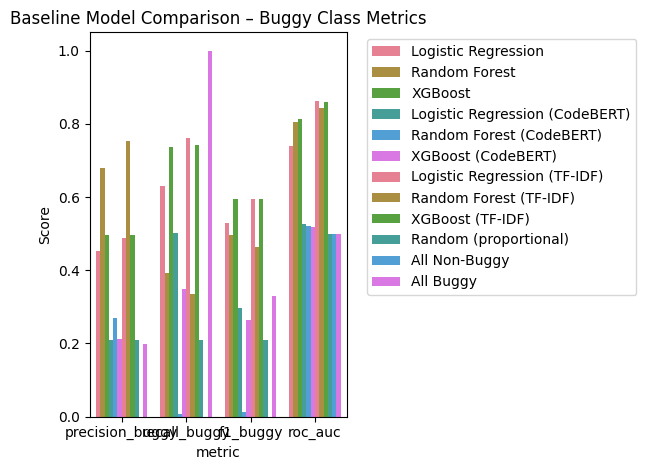

/tmp/ipykernel_1560177/712783174.py:33: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='model', y=metric, hue='model',
/tmp/ipykernel_1560177/712783174.py:33: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='model', y=metric, hue='model',
/tmp/ipykernel_1560177/712783174.py:33: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='model', y=metric, hue='model',
/tmp/ipykernel_1560177/712783174.py:33: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='model', y=metric, hue='model',


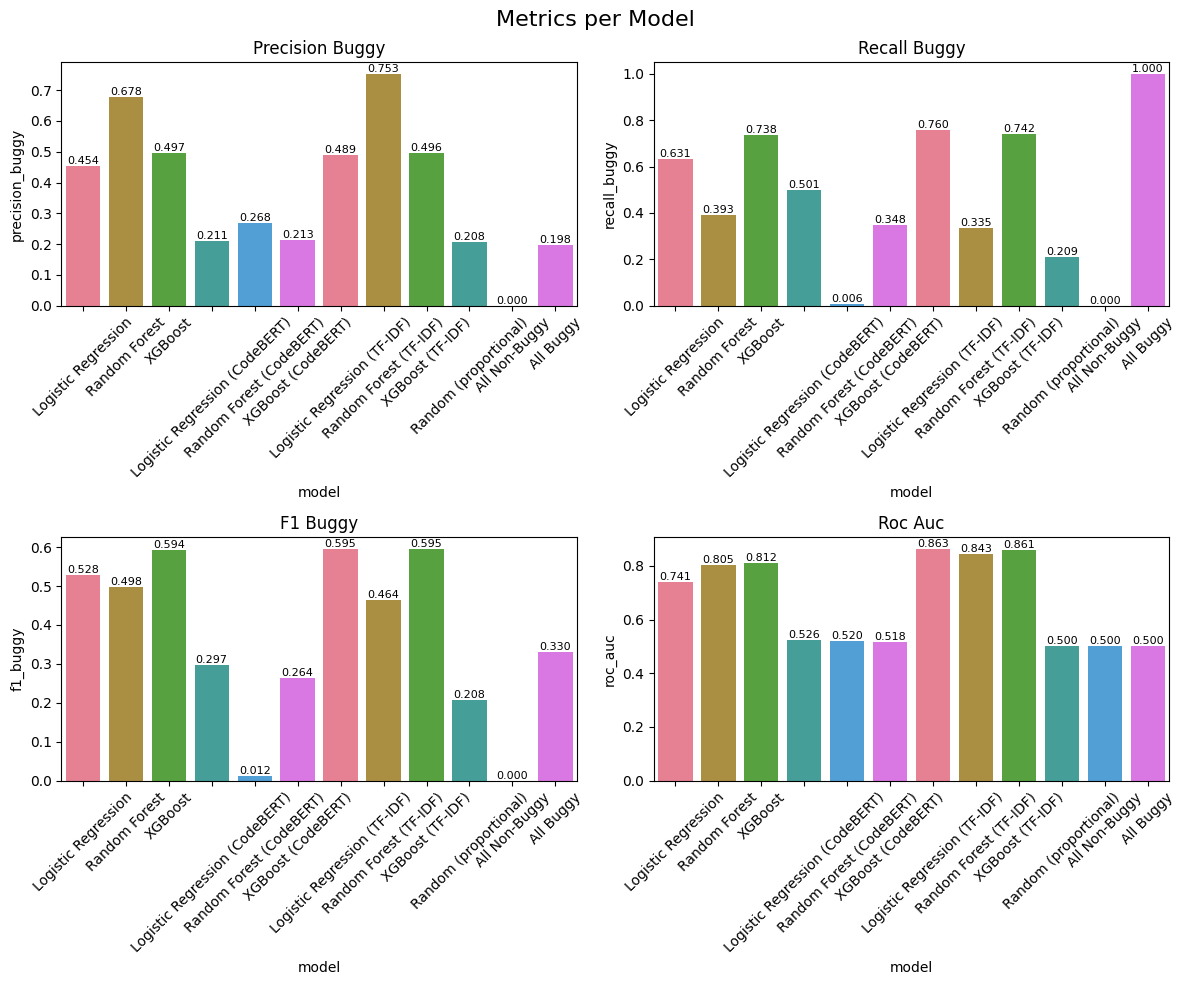

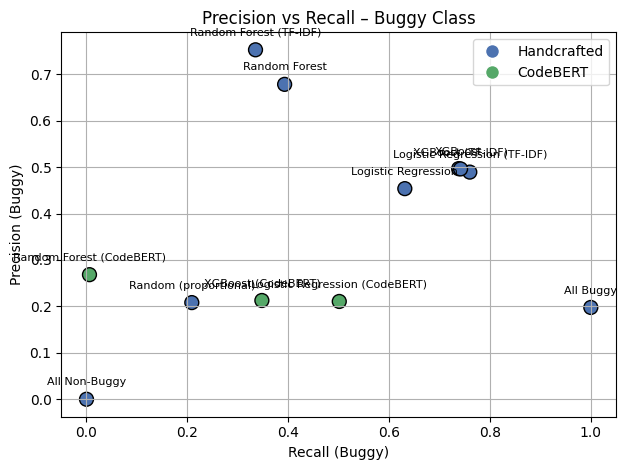

/tmp/ipykernel_1560177/712783174.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='f1_buggy', palette=sns.color_palette("husl", 6))
/tmp/ipykernel_1560177/712783174.py:68: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='model', y='f1_buggy', palette=sns.color_palette("husl", 6))


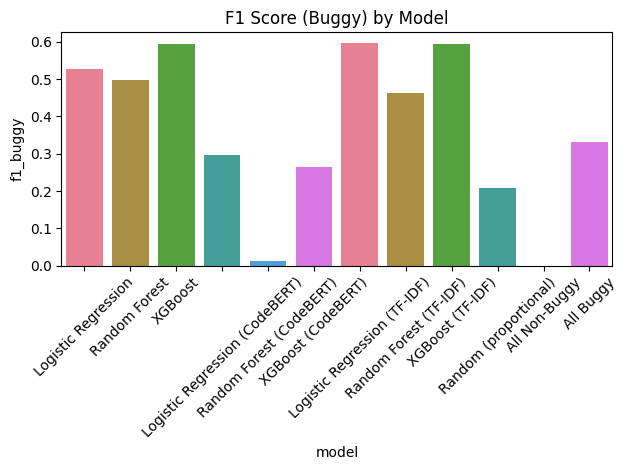

/tmp/ipykernel_1560177/712783174.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='model', y='roc_auc', palette=sns.color_palette("husl", 6))
/tmp/ipykernel_1560177/712783174.py:76: UserWarning: 
The palette list has fewer values (6) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df, x='model', y='roc_auc', palette=sns.color_palette("husl", 6))


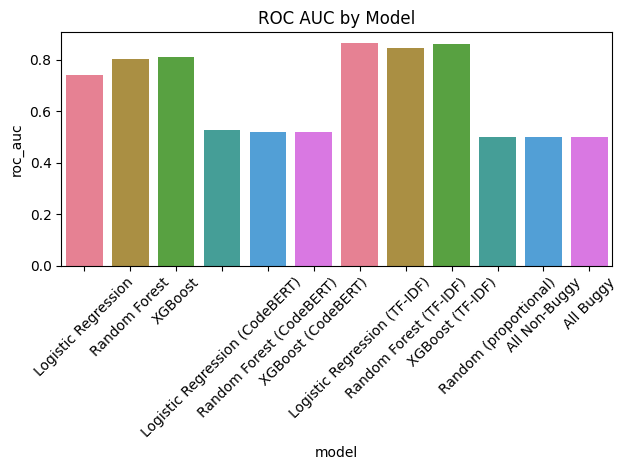

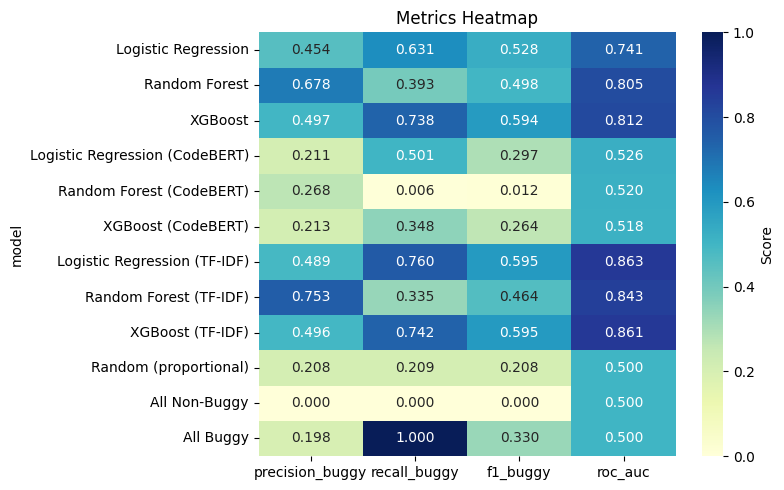

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results
df = pd.read_csv('baseline_results.csv')
print(df)


# Define approach grouping (reusable column)
df['approach'] = np.where(df['model'].str.contains('CodeBERT'), 'CodeBERT', 'Handcrafted')

metrics = ['precision_buggy', 'recall_buggy', 'f1_buggy', 'roc_auc']
group_colors = {'Handcrafted': '#4C72B0', 'CodeBERT': '#55A868'}

# 1. Grouped bar chart (all metrics, all models)
df_melted = df.melt(id_vars=['model', 'approach'], value_vars=metrics,
                    var_name='metric', value_name='value')

plt.figure()
sns.barplot(data=df_melted, x='metric', y='value', hue='model',
            palette=sns.color_palette("husl", 6))
plt.title('Baseline Model Comparison – Buggy Class Metrics')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Faceted bar charts (one subplot per metric)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, metric in zip(axes.flat, metrics):
    sns.barplot(data=df, x='model', y=metric, hue='model',
                palette=sns.color_palette("husl", 6), ax=ax, legend=False)
    ax.set_title(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
plt.suptitle('Metrics per Model', fontsize=16)
plt.tight_layout()
plt.show()

# 3. Precision – Recall scatter plot (fixed)
plt.figure()
# Use the already computed approach column
colors = [group_colors[a] for a in df['approach']]
plt.scatter(df['recall_buggy'], df['precision_buggy'], c=colors, s=100, edgecolors='k')
for i, row in df.iterrows():
    plt.annotate(row['model'], (row['recall_buggy'], row['precision_buggy']),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)

plt.xlabel('Recall (Buggy)')
plt.ylabel('Precision (Buggy)')
plt.title('Precision vs Recall – Buggy Class')
handles = [plt.Line2D([0],[0], marker='o', color='w', label='Handcrafted',
                     markerfacecolor=group_colors['Handcrafted'], markersize=10),
          plt.Line2D([0],[0], marker='o', color='w', label='CodeBERT',
                     markerfacecolor=group_colors['CodeBERT'], markersize=10)]
plt.legend(handles=handles)
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. F1 score bar chart
plt.figure()
sns.barplot(data=df, x='model', y='f1_buggy', palette=sns.color_palette("husl", 6))
plt.title('F1 Score (Buggy) by Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. ROC AUC bar chart
plt.figure()
sns.barplot(data=df, x='model', y='roc_auc', palette=sns.color_palette("husl", 6))
plt.title('ROC AUC by Model')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Heatmap of all metrics
heatmap_data = df.set_index('model')[metrics]
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlGnBu', cbar_kws={'label': 'Score'})
plt.title('Metrics Heatmap')
plt.tight_layout()
plt.show()

# Interpretation of Results

The final `baseline_results.csv` compares **12 models** across four evaluation metrics. Below is a summary and key insights.

## 1. Trivial baselines (the lower bound)

- **All Non‑Buggy** → precision = recall = F1 = 0, AUC = 0.5.  
- **All Buggy** → recall = 1.0, precision = buggy rate (≈19.8%), F1 = 0.330, AUC = 0.5.  
- **Random (proportional)** → precision ≈ recall ≈ F1 ≈ 0.208, AUC = 0.5.  

*Any useful model must significantly outperform these in both F1 and AUC.*

## 2. Handcrafted features (vanilla baselines)

Models trained on traditional software‑engineering attributes (e.g., churn, developer experience, file counts).

| Model | Precision | Recall | F1 | AUC |
|-------|-----------|--------|--- |---  |
| Logistic Regression | 0.454 | 0.631 | 0.528 | 0.741 |
| Random Forest | 0.678 | 0.393 | 0.498 | 0.805 |
| XGBoost | 0.497 | 0.738 | **0.594** | **0.812** |

- **XGBoost** gives the best balance (F1 = 0.594) with high recall, making it good for catching many defects.  
- **Random Forest** favours high precision at the cost of recall.  
- AUC values (0.74–0.81) confirm these models rank risky commits much better than random.

*Conclusion:* Curated software metrics capture defect‑prone patterns effectively and remain a solid baseline.

## 3. TF‑IDF on commit diffs (text baseline)

Using bag‑of‑words/ngrams on the `diff_text`.

| Model | Precision | Recall | F1 | AUC |
|-------|-----------|--------|--- |---  |
| Logistic Regression (TF‑IDF) | 0.489 | 0.760 | **0.595** | **0.863** |
| Random Forest (TF‑IDF) | 0.753 | 0.335 | 0.464 | 0.843 |
| XGBoost (TF‑IDF) | 0.496 | 0.742 | 0.594 | 0.861 |

- **Logistic Regression and XGBoost** achieve the highest F1 and AUC across **all** approaches, outperforming even handcrafted features.  
- The strong AUC (≈0.86) indicates excellent ranking capability.  
- Simple word patterns (e.g., “fix”, “bug”, “TODO”, changed API calls) provide powerful signals.

*Conclusion:* TF‑IDF is a remarkably strong baseline for JIT defect prediction when commit diffs are available. It combines high recall with decent precision and is computationally lightweight.

## 4. CodeBERT embeddings (pre‑trained, not fine‑tuned)

Mean‑pooled representations from a frozen CodeBERT model.

| Model | Precision | Recall | F1 | AUC |
|-------|-----------|--------|--- |---  |
| Logistic Regression (CodeBERT) | 0.211 | 0.501 | 0.297 | 0.526 |
| Random Forest (CodeBERT) | 0.268 | 0.006 | 0.012 | 0.520 |
| XGBoost (CodeBERT) | 0.213 | 0.348 | 0.264 | 0.518 |

- Performance is barely above random (AUC ≈ 0.52).  
- **Random Forest + CodeBERT** collapses to almost always predicting “non‑buggy” (recall = 0.6%).  
- The embeddings contain little discriminative signal for defect prediction in their current form.

*Why?*  
- CodeBERT is pre‑trained on general source code, not on bug‑prediction.  
- Many diffs are truncated to 512 tokens, losing information.  
- Off‑the‑shelf mean pooling dilutes task‑relevant signals.  
- Fine‑tuning the entire model (or using a model specifically trained on code changes) would likely improve performance drastically.

## Overall Takeaways

1. **TF‑IDF is the strongest baseline** – it beats handcrafted features in AUC and matches them in F1.  
2. **Handcrafted features remain valuable** – they encode domain knowledge and require no text preprocessing.  
3. **Raw CodeBERT embeddings do not work** – they need fine‑tuning or a different architecture to unlock their potential.  


The baselines now provide a clear performance ladder: **naive < CodeBERT (frozen) < handcrafted < TF‑IDF**.

# Per-project Baselines

In [ ]:
# TODO
#.
#.
#.
#.